# Detecting Vote-Buying in Thai Elections
## VAE v5 — Party Number Exception + Top Suspicious Slot Summary

### New in v5
1. **Party Number Exception**: If MP candidate in slot i belongs to a party whose number equals i, that slot is excluded from suspicious analysis — high correlation between mp_i and pl_i is expected naturally in this case.
2. **Top Suspicious Number Summary**: After detection, aggregate which slot numbers appear most often as suspicious across all flagged districts, and which party is associated with each.

### Feature Design (4 Group)

| Group | Features | Meaning |
|---|---|---|
| Baseline | `mp_1..10`, `pl_1..10` | raw score context |
| Joint High | `joint_i = mp_i × pl_i` | mp and lp have to high together, suspicious — fix false positive from low-vote pair |
| Min Vote | `min_i = min(mp_i, pl_i)` + mask if < 2% | fillter slot that low before calculate |
| Weighted Corr | `weighted_corr` (weight = `mp_i + pl_i`) | corr that not bias by low-vote slots |

## Section 1: Import

In [1]:
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
sns.set(font='Tahoma', style='whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## Section 2: Load Data (with partyCode per MP slot)

In [2]:
def extract_party_number(party_code: str) -> int:
    """
    Extract numeric suffix from partyCode.
    'PARTY-0046' -> 46,  'PARTY-003' -> 3
    Returns -1 on failure.
    """
    try:
        return int(party_code.split('-')[-1])
    except Exception:
        return -1


def load_election_data(base_path: str) -> pd.DataFrame:
    with open(os.path.join(base_path, 'area_code', 'area_code.json'),
              'r', encoding='utf-8') as f:
        areas = json.load(f)['areas']

    dataset = []
    for area in areas:
        code = str(area['code'])
        row  = {'area_code': code, 'area_name': area['name']}
        try:
            mp_path = os.path.join(base_path, 'mp', f'{code}.json')
            pl_path = os.path.join(base_path, 'pl', f'{code}.json')
            if not (os.path.exists(mp_path) and os.path.exists(pl_path)):
                continue

            with open(mp_path, 'r', encoding='utf-8') as f_mp, \
                 open(pl_path, 'r', encoding='utf-8') as f_pl:
                mp_data = json.load(f_mp)
                pl_data = json.load(f_pl)

            # Party list lookup by party number
            pl_pct = {}
            for e in pl_data['entries']:
                pnum = extract_party_number(e['partyCode'])
                pl_pct[pnum] = e['votePercent']

            # MP candidates: slot 1-10
            for i in range(1, 11):
                cand = next(
                    (e for e in mp_data['entries']
                     if int(str(e['candidateCode'])[-2:]) == i),
                    None
                )
                if cand:
                    mp_party_num = extract_party_number(cand['partyCode'])
                    row[f'mp_{i}']            = cand['votePercent']
                    row[f'mp_party_code_{i}'] = cand['partyCode']
                    row[f'mp_party_num_{i}']  = mp_party_num
                    # Exception: MP in slot i belongs to party #i
                    # -> high joint is EXPECTED, not suspicious
                    row[f'same_num_{i}'] = (mp_party_num == i)
                else:
                    row[f'mp_{i}']            = 0.0
                    row[f'mp_party_code_{i}'] = None
                    row[f'mp_party_num_{i}']  = -1
                    row[f'same_num_{i}']      = False

            # Party list votes for slots 1-10
            for i in range(1, 11):
                row[f'pl_{i}'] = pl_pct.get(i, 0.0)

            dataset.append(row)

        except Exception as e:
            print(f'Skip {code}: {e}')

    return pd.DataFrame(dataset).fillna(0)


BASE_PATH = r"C:\Users\New\OneDrive\Desktop\jupyter\AppliedML\project\election_69_analyzer-master\data"
df = load_election_data(BASE_PATH)
print(f'Loaded {len(df)} districts')

same_num_cols = [f'same_num_{i}' for i in range(1, 11)]
n_exc = int(df[same_num_cols].sum().sum())
print(f'Excepted slot-district pairs (MP party# == slot#): {n_exc}')

# Preview exceptions
exc_rows = []
for i in range(1, 11):
    sub = df[df[f'same_num_{i}']][['area_name', f'mp_party_code_{i}',
                                    f'mp_{i}', f'pl_{i}']].copy()
    sub.columns = ['area_name', 'party_code', 'mp_pct', 'pl_pct']
    sub.insert(0, 'slot', i)
    exc_rows.append(sub)
if exc_rows:
    exc_df = pd.concat(exc_rows).sort_values('slot').reset_index(drop=True)
    print('\nSample exceptions:')
    print(exc_df.head(15).to_string(index=False))

Loaded 400 districts
Excepted slot-district pairs (MP party# == slot#): 56

Sample exceptions:
 slot                       area_name party_code  mp_pct  pl_pct
    6          Bangkok Constituency 1 PARTY-0006    2.70    2.38
    6 Ubon Ratchathani Constituency 8 PARTY-0006    0.33    1.56
    6        Uttaradit Constituency 3 PARTY-0006    1.61    2.24
    6       Udon Thani Constituency 6 PARTY-0006    0.63    1.17
    6            Surin Constituency 8 PARTY-0006    0.58    1.35
    6        Sukhothai Constituency 3 PARTY-0006    1.49    2.40
    6            Satun Constituency 1 PARTY-0006    0.56    1.29
    6         Songkhla Constituency 4 PARTY-0006    0.51    1.19
    6     Sakon Nakhon Constituency 5 PARTY-0006    0.42    1.42
    6             Loei Constituency 3 PARTY-0006    0.97    1.42
    6          Lampang Constituency 3 PARTY-0006    1.68    1.78
    6       Ratchaburi Constituency 2 PARTY-0006    3.09    3.54
    6           Rayong Constituency 1 PARTY-0006    1.29    

## Section 3: Feature Engineering

For every slot i where `same_num_i == True`, all derived features (`joint_i`, `min_i`) are set to 0 and the slot is excluded from weighted correlation — so the model cannot mistake naturally aligned voting for suspicious behavior.

In [3]:
mp_cols = [f'mp_{i}' for i in range(1, 11)]
pl_cols = [f'pl_{i}' for i in range(1, 11)]
MIN_VOTE_THRESHOLD = 2.0

# joint_i = mp_i * pl_i  (zeroed for excepted slots)
for i in range(1, 11):
    raw = df[f'mp_{i}'] * df[f'pl_{i}']
    df[f'joint_{i}'] = np.where(df[f'same_num_{i}'], 0.0, raw)
joint_cols = [f'joint_{i}' for i in range(1, 11)]

# min_vote_i = min(mp_i, pl_i) masked at 2%  (zeroed for excepted slots)
for i in range(1, 11):
    raw_min = np.minimum(df[f'mp_{i}'], df[f'pl_{i}'])
    masked  = np.where(raw_min >= MIN_VOTE_THRESHOLD, raw_min, 0.0)
    df[f'min_{i}'] = np.where(df[f'same_num_{i}'], 0.0, masked)
min_cols = [f'min_{i}' for i in range(1, 11)]

# Weighted correlation  (excepted slots zeroed before computing)
def weighted_corr_excepted(row):
    mp_v = np.array([row[f'mp_{i}'] for i in range(1, 11)], dtype=float)
    pl_v = np.array([row[f'pl_{i}'] for i in range(1, 11)], dtype=float)
    exc  = np.array([bool(row[f'same_num_{i}']) for i in range(1, 11)])
    mp_v[exc] = 0.0
    pl_v[exc] = 0.0
    w = mp_v + pl_v
    if w.sum() == 0:
        return 0.0
    w    = w / w.sum()
    mp_w = np.sum(w * mp_v)
    pl_w = np.sum(w * pl_v)
    cov    = np.sum(w * (mp_v - mp_w) * (pl_v - pl_w))
    std_mp = np.sqrt(np.sum(w * (mp_v - mp_w) ** 2))
    std_pl = np.sqrt(np.sum(w * (pl_v - pl_w) ** 2))
    if std_mp == 0 or std_pl == 0:
        return 0.0
    return float(cov / (std_mp * std_pl))

df['weighted_corr'] = df.apply(weighted_corr_excepted, axis=1)

feature_cols = mp_cols + pl_cols + joint_cols + min_cols + ['weighted_corr']
INPUT_DIM    = len(feature_cols)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols].values).astype(np.float32)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

print(f'Feature matrix : {X_scaled.shape}')
print(f'  Baseline      : 20  (mp+pl)')
print(f'  Joint high    : 10')
print(f'  Min vote      : 10  (masked <{MIN_VOTE_THRESHOLD}%, excepted zeroed)')
print(f'  Weighted corr :  1')
print(f'  Total         : {INPUT_DIM}')

Feature matrix : (400, 41)
  Baseline      : 20  (mp+pl)
  Joint high    : 10
  Min vote      : 10  (masked <2.0%, excepted zeroed)
  Weighted corr :  1
  Total         : 41


## Section 4: VAE Model

In [4]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=24, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU()
        )
        self.fc_mu      = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim // 2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def reparameterize(self, mu, log_var):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * log_var)
        return mu

    def forward(self, x):
        h = self.encoder(x)
        mu, log_var = self.fc_mu(h), self.fc_log_var(h)
        return self.decoder(self.reparameterize(mu, log_var)), mu, log_var


def elbo_loss(x_recon, x, mu, log_var, beta=1.5):
    recon = nn.functional.mse_loss(x_recon, x, reduction='sum')
    kl    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return (recon + beta * kl) / x.size(0)


def train_vae(model, X_tensor, n_epochs=500, lr=1e-3, beta=1.5, batch_size=64):
    loader    = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=30, factor=0.5)
    history   = []
    for epoch in range(1, n_epochs + 1):
        model.train()
        total = 0.0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            x_r, mu, lv = model(batch)
            loss = elbo_loss(x_r, batch, mu, lv, beta)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item()
        avg = total / len(loader)
        history.append(avg)
        scheduler.step(avg)
        if epoch % 100 == 0:
            print(f'  Epoch {epoch:4d} | Loss: {avg:.4f}')
    return history


def get_elbo_per_sample(model, X_tensor, beta=1.5, n_mc=50):
    scores = []
    X_dev  = X_tensor.to(DEVICE)
    with torch.no_grad():
        for _ in range(n_mc):
            model.train()
            x_r, mu, lv = model(X_dev)
            recon = nn.functional.mse_loss(x_r, X_dev, reduction='none').mean(dim=1)
            kl    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp(), dim=1)
            scores.append((recon + beta * kl).cpu().numpy())
    model.eval()
    return np.mean(scores, axis=0)

print('VAE defined.')

VAE defined.


## Section 5: Iterative Refinement Training

In [5]:
HIDDEN_DIM  = 24
LATENT_DIM  = 4
N_EPOCHS    = 500
LR          = 1e-3
BETA        = 1.5
CLEAN_RATIO = 0.80
N_REFINE    = 4

all_histories = []
clean_mask    = np.ones(len(X_scaled), dtype=bool)

for it in range(1, N_REFINE + 1):
    print(f'\n=== Round {it}/{N_REFINE} — training on {clean_mask.sum()} districts ===')
    model   = VAE(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(DEVICE)
    history = train_vae(model, X_tensor[clean_mask], N_EPOCHS, LR, BETA)
    all_histories.append(history)
    scores     = get_elbo_per_sample(model, X_tensor, BETA)
    threshold  = np.percentile(scores, CLEAN_RATIO * 100)
    clean_mask = scores <= threshold
    print(f'  Final loss: {history[-1]:.4f} | Next clean: {clean_mask.sum()} districts')

df['elbo_score']    = scores
df['anomaly_score'] = (scores - scores.min()) / (scores.max() - scores.min())
print('\nDone.')


=== Round 1/4 — training on 400 districts ===
  Epoch  100 | Loss: 30.0780
  Epoch  200 | Loss: 25.2950
  Epoch  300 | Loss: 23.4495
  Epoch  400 | Loss: 20.8739
  Epoch  500 | Loss: 19.2792
  Final loss: 19.2792 | Next clean: 320 districts

=== Round 2/4 — training on 320 districts ===
  Epoch  100 | Loss: 20.4666
  Epoch  200 | Loss: 18.3724
  Epoch  300 | Loss: 17.7539
  Epoch  400 | Loss: 17.4600
  Epoch  500 | Loss: 17.0725
  Final loss: 17.0725 | Next clean: 320 districts

=== Round 3/4 — training on 320 districts ===
  Epoch  100 | Loss: 27.9290
  Epoch  200 | Loss: 20.6967
  Epoch  300 | Loss: 18.6502
  Epoch  400 | Loss: 18.0982
  Epoch  500 | Loss: 17.5184
  Final loss: 17.5184 | Next clean: 320 districts

=== Round 4/4 — training on 320 districts ===
  Epoch  100 | Loss: 23.2574
  Epoch  200 | Loss: 19.4689
  Epoch  300 | Loss: 17.2572
  Epoch  400 | Loss: 17.0981
  Epoch  500 | Loss: 16.4589
  Final loss: 16.4589 | Next clean: 320 districts

Done.


## Section 6: Threshold & Sensitivity

In [6]:
pct_levels = [85, 90, 92, 95]
sens = {p: set(df.loc[df['elbo_score'] > np.percentile(df['elbo_score'], p), 'area_name'])
        for p in pct_levels}
robust_anomalies = set.intersection(*sens.values())
df['is_anomaly']  = df['elbo_score'] > np.percentile(df['elbo_score'], 90)
df['is_robust']   = df['area_name'].isin(robust_anomalies)

print(f'Flagged (top 10%): {df["is_anomaly"].sum()}')
print(f'Robust anomalies : {len(robust_anomalies)}')

Flagged (top 10%): 40
Robust anomalies : 20


## Section 7: Visualizations

### Plot 1 — Training Loss per Refinement Round
Shows ELBO loss across epochs for each refinement round. Loss converging downward confirms the model is learning the normal distribution. If round 2 and 3 start lower than round 1, it confirms that iteratively removing anomalies before retraining reduces contamination effectively.

### Plot 2 — Mean joint_high (mp×pl) per Slot
Compares average mp_i × pl_i per slot between anomaly and normal districts. Excepted slots are already zeroed. A taller red bar in slot i means that slot sees both MP and party list receive unusually high votes simultaneously in anomaly districts — the primary vote-buying signal.

### Plot 3 — Mean min_vote (masked) per Slot
Shows average min(mp_i, pl_i) after the 2% mask and exception zeroing. High red bars confirm that even the lower-voted side of the pair is still meaningfully high — eliminating the low-vote false positive case entirely.

### Plot 4 — Weighted Correlation Distribution
Distribution of weighted correlation with low-vote and excepted slots removed. A rightward shift in the anomaly group means their mp and pl patterns track each other in the high-vote slots specifically, consistent with coordinated same-number voting.

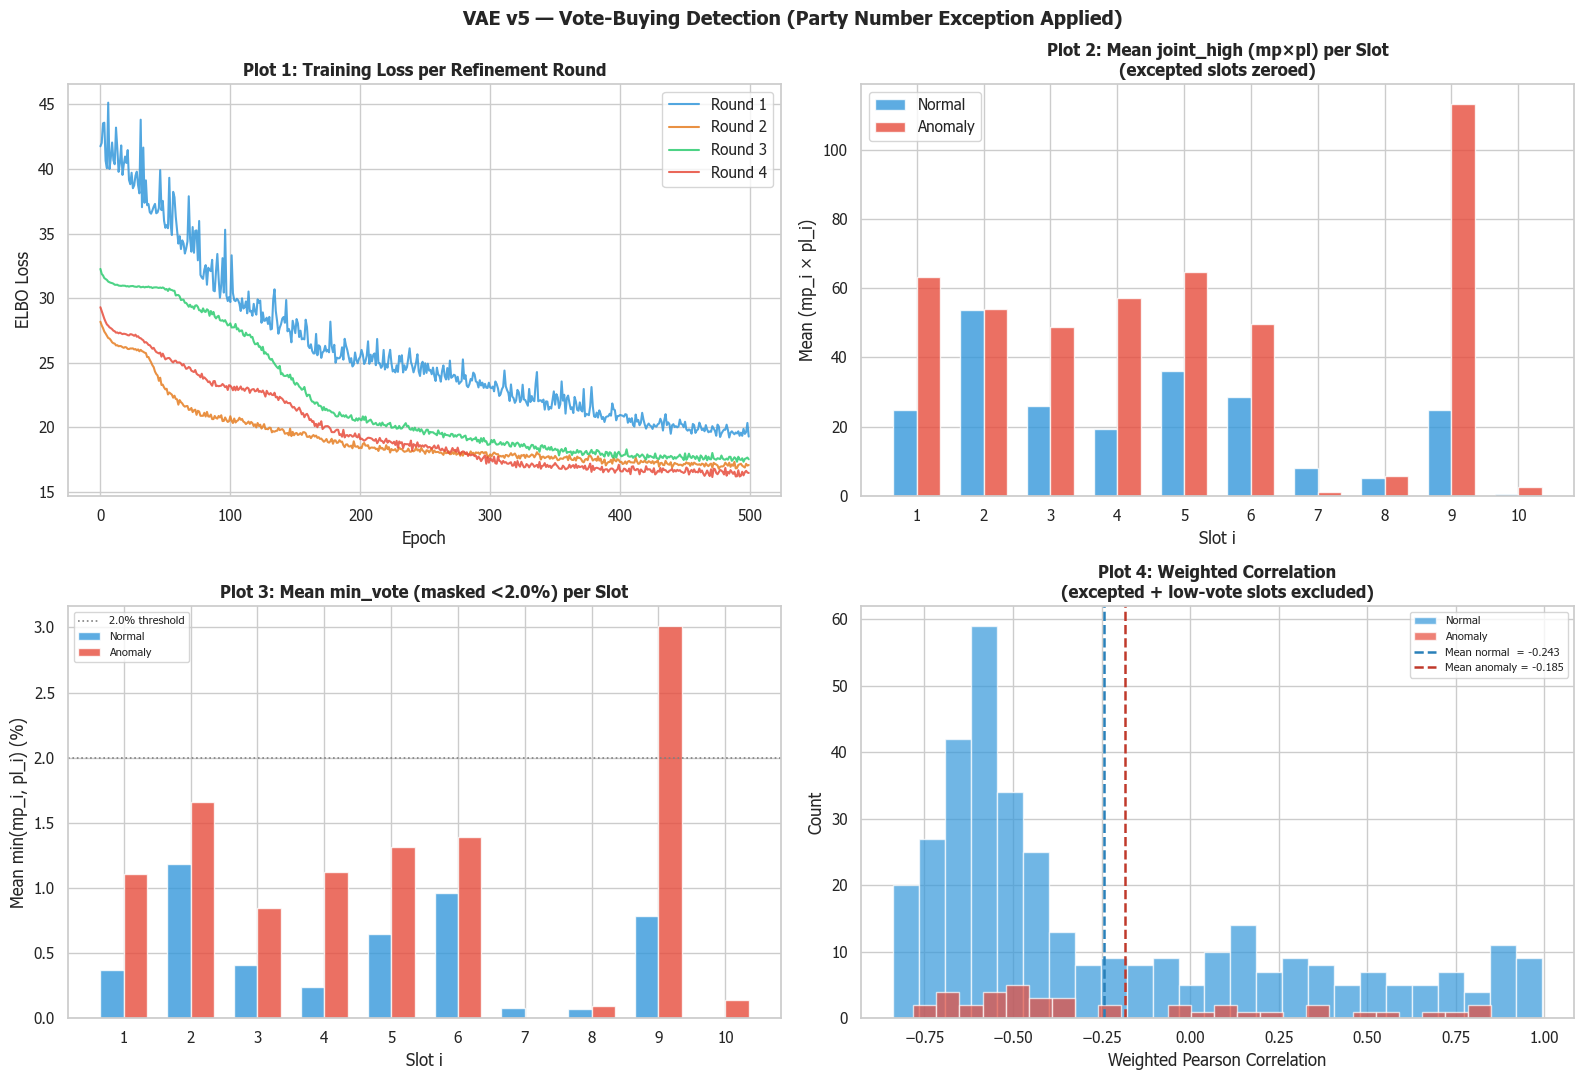

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('VAE v5 — Vote-Buying Detection (Party Number Exception Applied)',
             fontsize=14, fontweight='bold')

ax = axes[0, 0]
for i, hist in enumerate(all_histories):
    ax.plot(hist, linewidth=1.5, alpha=0.85,
            color=['#3498db', '#e67e22', '#2ecc71', '#e74c3c'][i], label=f'Round {i+1}')
ax.set_title('Plot 1: Training Loss per Refinement Round', fontweight='bold')
ax.set_xlabel('Epoch') ; ax.set_ylabel('ELBO Loss') ; ax.legend()

ax = axes[0, 1]
x, w = np.arange(1, 11), 0.35
ax.bar(x-w/2, [df[~df['is_anomaly']][f'joint_{i}'].mean() for i in range(1,11)],
       w, label='Normal',  color='#3498db', alpha=0.8)
ax.bar(x+w/2, [df[ df['is_anomaly']][f'joint_{i}'].mean() for i in range(1,11)],
       w, label='Anomaly', color='#e74c3c', alpha=0.8)
ax.set_title('Plot 2: Mean joint_high (mp×pl) per Slot\n(excepted slots zeroed)', fontweight='bold')
ax.set_xlabel('Slot i') ; ax.set_ylabel('Mean (mp_i × pl_i)') ; ax.set_xticks(x) ; ax.legend()

ax = axes[1, 0]
ax.bar(x-w/2, [df[~df['is_anomaly']][f'min_{i}'].mean() for i in range(1,11)],
       w, label='Normal',  color='#3498db', alpha=0.8)
ax.bar(x+w/2, [df[ df['is_anomaly']][f'min_{i}'].mean() for i in range(1,11)],
       w, label='Anomaly', color='#e74c3c', alpha=0.8)
ax.axhline(MIN_VOTE_THRESHOLD, color='gray', linestyle=':', linewidth=1.2,
           label=f'{MIN_VOTE_THRESHOLD}% threshold')
ax.set_title(f'Plot 3: Mean min_vote (masked <{MIN_VOTE_THRESHOLD}%) per Slot', fontweight='bold')
ax.set_xlabel('Slot i') ; ax.set_ylabel('Mean min(mp_i, pl_i) (%)') ; ax.set_xticks(x) ; ax.legend(fontsize=8)

ax = axes[1, 1]
ax.hist(df[~df['is_anomaly']]['weighted_corr'], bins=25, alpha=0.7, color='#3498db', label='Normal')
ax.hist(df[ df['is_anomaly']]['weighted_corr'], bins=25, alpha=0.7, color='#e74c3c', label='Anomaly')
mn_c = df[~df['is_anomaly']]['weighted_corr'].mean()
ma_c = df[ df['is_anomaly']]['weighted_corr'].mean()
ax.axvline(mn_c, color='#2980b9', linestyle='--', linewidth=1.8, label=f'Mean normal  = {mn_c:.3f}')
ax.axvline(ma_c, color='#c0392b', linestyle='--', linewidth=1.8, label=f'Mean anomaly = {ma_c:.3f}')
ax.set_title('Plot 4: Weighted Correlation\n(excepted + low-vote slots excluded)', fontweight='bold')
ax.set_xlabel('Weighted Pearson Correlation') ; ax.set_ylabel('Count') ; ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('vae_v5_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Per-District Report — Which District, Which Slot

A slot is suspicious when **all three** hold:
1. `same_num_i == False`  (not a natural party-number match)
2. `joint_i >= Q75`       (both mp and pl high simultaneously)
3. `min(mp_i, pl_i) >= 2%` (not a low-vote false positive)

In [8]:
joint_q75 = {i: np.percentile(df[f'joint_{i}'], 75) for i in range(1, 11)}
joint_q90 = {i: np.percentile(df[f'joint_{i}'], 90) for i in range(1, 11)}

def get_suspicious_slots(row):
    sus = []
    for i in range(1, 11):
        if bool(row[f'same_num_{i}']):       # natural match — skip
            continue
        mp_v  = row[f'mp_{i}']
        pl_v  = row[f'pl_{i}']
        joint = mp_v * pl_v
        if joint >= joint_q75[i] and min(mp_v, pl_v) >= MIN_VOTE_THRESHOLD:
            sus.append({
                'slot'       : i,
                'mp'         : round(mp_v, 2),
                'pl'         : round(pl_v, 2),
                'joint'      : round(joint, 2),
                'party_code' : row[f'mp_party_code_{i}'],
                'party_num'  : int(row[f'mp_party_num_{i}']),
                'level'      : 'very high' if joint >= joint_q90[i] else 'high',
            })
    return sus

df['suspicious_slots']   = df.apply(get_suspicious_slots, axis=1)
df['n_suspicious_slots'] = df['suspicious_slots'].apply(len)

print('=' * 80)
print('SUSPICIOUS DISTRICTS — Slot-Level Report')
print('Criteria: top 10% ELBO  |  joint > Q75  |  min(mp,pl) >= 2%  |  no party-number match')
print('=' * 80)

for _, row in df[df['is_anomaly']].sort_values(
        ['is_robust', 'anomaly_score'], ascending=[False, False]).iterrows():
    tag = '[ROBUST]' if row['is_robust'] else ''
    print(f"\n{'─'*70}")
    print(f"District : {row['area_name']}  {tag}")
    print(f"  Anomaly Score    : {row['anomaly_score']:.3f}")
    print(f"  Weighted Corr    : {row['weighted_corr']:.3f}")
    print(f"  Suspicious Slots : {row['n_suspicious_slots']}")
    if row['suspicious_slots']:
        print(f"  {'Slot':<6} {'MP%':>7} {'PL%':>7} {'joint':>9}  {'Party Code':<16}  Level")
        print(f"  {'─'*68}")
        for s in row['suspicious_slots']:
            print(f"  #{s['slot']:<5}  {s['mp']:>6.2f}%  {s['pl']:>6.2f}%  "
                  f"{s['joint']:>9.2f}  {str(s['party_code']):<16}  {s['level']}")
    else:
        print('  (pattern-level anomaly — no individual slot passes all 3 criteria)')

print(f"\n{'='*80}")
print(f"Total flagged    : {df['is_anomaly'].sum()} districts")
print(f"Robust anomalies : {df['is_robust'].sum()} districts")

SUSPICIOUS DISTRICTS — Slot-Level Report
Criteria: top 10% ELBO  |  joint > Q75  |  min(mp,pl) >= 2%  |  no party-number match

──────────────────────────────────────────────────────────────────────
District : Chiang Mai Constituency 10  [ROBUST]
  Anomaly Score    : 1.000
  Weighted Corr    : -0.603
  Suspicious Slots : 2
  Slot       MP%     PL%     joint  Party Code        Level
  ────────────────────────────────────────────────────────────────────
  #1       38.56%    5.88%     226.73  PARTY-0009        very high
  #4       41.44%    5.12%     212.17  PARTY-0042        very high

──────────────────────────────────────────────────────────────────────
District : Lopburi Constituency 1  [ROBUST]
  Anomaly Score    : 0.717
  Weighted Corr    : 0.850
  Suspicious Slots : 2
  Slot       MP%     PL%     joint  Party Code        Level
  ────────────────────────────────────────────────────────────────────
  #8       40.53%    3.85%     156.04  PARTY-0037        very high
  #10      15.80%  

## Section 9: Aggregate — Top Suspicious Slot Numbers & Parties

=== Top Suspicious Slot Numbers ===
 slot  n_districts  robust_count   mean_mp   mean_pl  mean_joint  top_party
    4           13             8 49.186923  3.456923  171.522308 PARTY-0042
    5           12             6 40.964167  4.394167  196.620833 PARTY-0009
    1           10             5 49.598000  4.436000  230.555000 PARTY-0009
    9           10             5 14.292000 32.350000  441.342000 PARTY-0011
    2            9             5 34.836667  5.138889  200.547778 PARTY-0009
    3            9             4 50.078889  3.775556  200.898889 PARTY-0037
    6            9             3 37.307778  5.142222  207.263333 PARTY-0009
   10            2             2 18.665000  2.825000   51.825000 PARTY-0044
    8            1             1 40.530000  3.850000  156.040000 PARTY-0037

=== Top Party Codes in Suspicious Slots ===
party_code  n_districts               slots_seen  mean_joint  robust_count
PARTY-0009           23   [1, 2, 3, 4, 5, 6, 10]  176.389130            12
PARTY-003

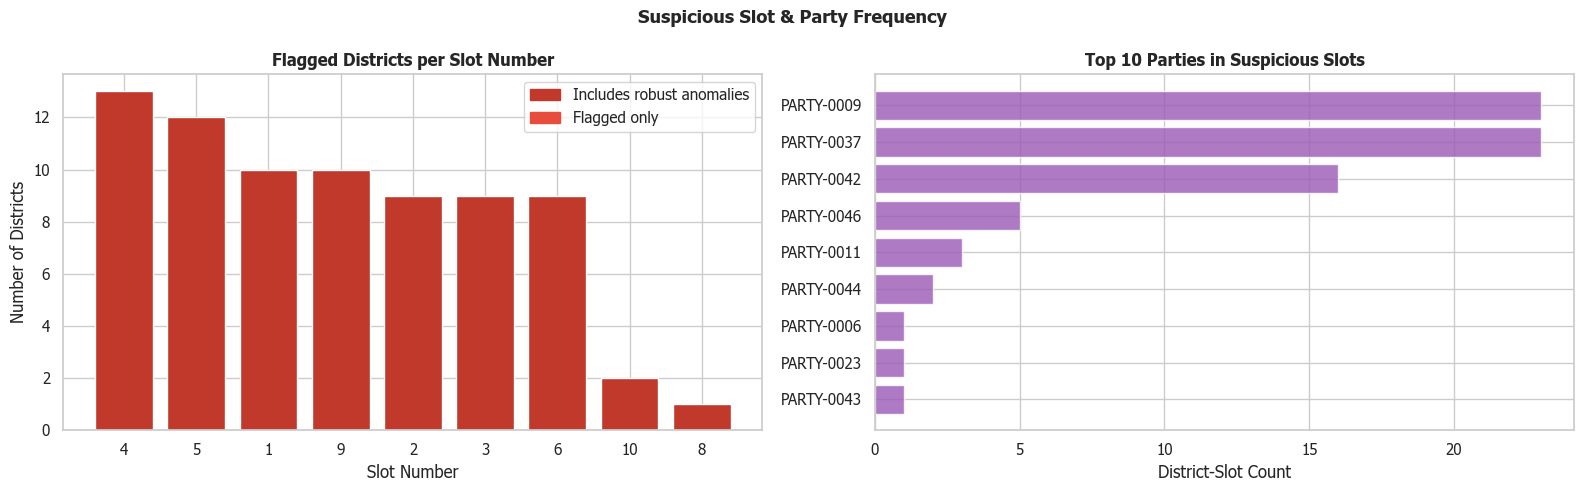

In [9]:
slot_records = []
for _, row in df[df['is_anomaly']].iterrows():
    for s in row['suspicious_slots']:
        slot_records.append({
            'district'     : row['area_name'],
            'slot'         : s['slot'],
            'party_code'   : s['party_code'],
            'party_num'    : s['party_num'],
            'mp_pct'       : s['mp'],
            'pl_pct'       : s['pl'],
            'joint'        : s['joint'],
            'level'        : s['level'],
            'anomaly_score': row['anomaly_score'],
            'is_robust'    : row['is_robust'],
        })

if slot_records:
    sr = pd.DataFrame(slot_records)

    slot_freq = (
        sr.groupby('slot')
        .agg(
            n_districts  = ('district', 'count'),
            robust_count = ('is_robust', 'sum'),
            mean_mp      = ('mp_pct', 'mean'),
            mean_pl      = ('pl_pct', 'mean'),
            mean_joint   = ('joint', 'mean'),
        )
        .sort_values('n_districts', ascending=False)
        .reset_index()
    )
    slot_freq['top_party'] = slot_freq['slot'].apply(
        lambda s: sr[sr['slot']==s]['party_code'].value_counts().idxmax()
                  if not sr[sr['slot']==s]['party_code'].isna().all() else 'N/A'
    )

    party_freq = (
        sr.groupby('party_code')
        .agg(
            n_districts  = ('district', 'count'),
            slots_seen   = ('slot', lambda x: sorted(x.unique().tolist())),
            mean_joint   = ('joint', 'mean'),
            robust_count = ('is_robust', 'sum'),
        )
        .sort_values('n_districts', ascending=False)
        .reset_index()
    )

    print('=== Top Suspicious Slot Numbers ===')
    print(slot_freq.to_string(index=False))
    print('\n=== Top Party Codes in Suspicious Slots ===')
    print(party_freq.head(15).to_string(index=False))

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Suspicious Slot & Party Frequency', fontsize=13, fontweight='bold')

    ax = axes[0]
    bar_colors = ['#c0392b' if r > 0 else '#e74c3c' for r in slot_freq['robust_count']]
    ax.bar(slot_freq['slot'].astype(str), slot_freq['n_districts'], color=bar_colors)
    ax.set_title('Flagged Districts per Slot Number', fontweight='bold')
    ax.set_xlabel('Slot Number') ; ax.set_ylabel('Number of Districts')
    ax.legend(handles=[
        mpatches.Patch(color='#c0392b', label='Includes robust anomalies'),
        mpatches.Patch(color='#e74c3c', label='Flagged only'),
    ])

    ax = axes[1]
    top_p = party_freq.head(10)
    ax.barh(top_p['party_code'].astype(str), top_p['n_districts'],
            color='#9b59b6', alpha=0.8)
    ax.set_title('Top 10 Parties in Suspicious Slots', fontweight='bold')
    ax.set_xlabel('District-Slot Count') ; ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig('vae_v5_slot_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    sr = pd.DataFrame()
    slot_freq  = pd.DataFrame()
    party_freq = pd.DataFrame()
    print('No suspicious slots found.')

## Section 11: Suspicious Slot Detail Report

Re-reads the raw JSON files to surface the **full candidate and party info**
for every suspicious slot in every flagged district.

For each `(district, slot)` pair that passes all three criteria, we show:

| Side | Fields |
|------|--------|
| MP   | candidateCode, partyCode, rank, voteTotal, votePercent |
| PL   | partyCode, rank, voteTotal, votePercent |

**Sorting**: districts ordered by number of suspicious slots (desc), then mean joint score (desc).
Slots within a district are sorted by slot number.

> Slots where the MP candidate belongs to the same-numbered party are **excluded** before this step.


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 11 — Suspicious Slot Detail Report
# ══════════════════════════════════════════════════════════════════════════════
# Re-reads raw JSON to get rank + voteTotal for MP and PL.
# Only district-slot pairs that pass ALL criteria are shown:
#   1. same_num_i == False          (no natural party-number match)
#   2. mp_pct >= MIN_VOTE_THRESHOLD (not a low-vote pair)
#   3. pl_pct >= MIN_VOTE_THRESHOLD (not a low-vote pair)
#   4. joint = mp_pct * pl_pct >= Q75 for that slot
# ══════════════════════════════════════════════════════════════════════════════

# ── Step 1: re-read raw JSON to collect rank + voteTotal for slots 1-10 ──────
mp_detail_rows = []
pl_detail_rows = []

with open(os.path.join(BASE_PATH, 'area_code', 'area_code.json'),
          'r', encoding='utf-8') as _f:
    _areas = json.load(_f)['areas']

for _area in _areas:
    _code = str(_area['code'])
    _name = _area['name']
    _mp_p = os.path.join(BASE_PATH, 'mp', f'{_code}.json')
    _pl_p = os.path.join(BASE_PATH, 'pl', f'{_code}.json')
    if not (os.path.exists(_mp_p) and os.path.exists(_pl_p)):
        continue
    try:
        with open(_mp_p, 'r', encoding='utf-8') as _f:
            _mp = json.load(_f)
        with open(_pl_p, 'r', encoding='utf-8') as _f:
            _pl = json.load(_f)

        # MP: collect all entries for slots 1-10
        for e in _mp.get('entries', []):
            try:
                _slot = int(str(e['candidateCode'])[-2:])
            except Exception:
                continue
            if 1 <= _slot <= 10:
                mp_detail_rows.append({
                    'area_code'      : _code,
                    'area_name'      : _name,
                    'slot'           : _slot,
                    'mp_candidate'   : e.get('candidateCode', ''),
                    'mp_party_code'  : e.get('partyCode', ''),
                    'mp_party_num'   : extract_party_number(e.get('partyCode', '')),
                    'mp_rank'        : e.get('rank', None),
                    'mp_vote_total'  : int(e.get('voteTotal', 0) or 0),
                    'mp_vote_pct'    : float(e.get('votePercent', 0.0) or 0.0),
                })

        # PL: collect all entries for party numbers 1-10
        for e in _pl.get('entries', []):
            _pnum = extract_party_number(e.get('partyCode', ''))
            if 1 <= _pnum <= 10:
                pl_detail_rows.append({
                    'area_code'      : _code,
                    'area_name'      : _name,
                    'slot'           : _pnum,
                    'pl_party_code'  : e.get('partyCode', ''),
                    'pl_rank'        : e.get('rank', None),
                    'pl_vote_total'  : int(e.get('voteTotal', 0)
                                          or e.get('totalVotes', 0) or 0),
                    'pl_vote_pct'    : float(e.get('votePercent', 0.0) or 0.0),
                })
    except Exception:
        pass

df_mp_det = pd.DataFrame(mp_detail_rows)
df_pl_det = pd.DataFrame(pl_detail_rows)
print(f'MP detail rows: {len(df_mp_det):,}  |  PL detail rows: {len(df_pl_det):,}')

# ── Step 2: merge MP + PL on area_code + slot ─────────────────────────────────
det = df_mp_det.merge(df_pl_det, on=['area_code', 'area_name', 'slot'], how='inner')
det['joint'] = det['mp_vote_pct'] * det['pl_vote_pct']

# ── Step 3: compute per-slot Q75 / Q90 of joint ───────────────────────────────
_jq75 = det.groupby('slot')['joint'].quantile(0.75).to_dict()
_jq90 = det.groupby('slot')['joint'].quantile(0.90).to_dict()

# ── Step 4: apply suspicious criteria ────────────────────────────────────────
def _is_sus(row):
    if row['mp_party_num'] == row['slot']:        # natural match — exclude
        return False
    if row['mp_vote_pct'] < MIN_VOTE_THRESHOLD:   # low-vote pair
        return False
    if row['pl_vote_pct'] < MIN_VOTE_THRESHOLD:   # low-vote pair
        return False
    return row['joint'] >= _jq75.get(row['slot'], float('inf'))

det['suspicious'] = det.apply(_is_sus, axis=1)
det['level']      = det.apply(
    lambda r: 'VERY HIGH' if r['joint'] >= _jq90.get(r['slot'], float('inf'))
              else ('HIGH' if r['suspicious'] else 'normal'),
    axis=1
)

sus_det = det[det['suspicious']].copy()
print(f'Suspicious district-slot pairs : {len(sus_det)}')
print(f'Unique districts flagged       : {sus_det["area_name"].nunique()}')
print(f'Unique slots flagged           : {sorted(sus_det["slot"].unique().tolist())}')

# ── Step 5: sort districts by n_sus_slots desc, then mean_joint desc ──────────
_rank_df = (
    sus_det.groupby('area_name')
    .agg(n_sus_slots=('slot', 'count'), mean_joint=('joint', 'mean'))
    .sort_values(['n_sus_slots', 'mean_joint'], ascending=[False, False])
)

# ── Step 6: print detailed report ────────────────────────────────────────────
print()
print('=' * 90)
print('SUSPICIOUS SLOT DETAIL REPORT')
print(f'Criteria : mp% >= {MIN_VOTE_THRESHOLD}%  |  pl% >= {MIN_VOTE_THRESHOLD}%  '
      f'|  joint >= Q75  |  MP party# != slot#')
print('=' * 90)

for area_name, _ginfo in _rank_df.iterrows():
    _slots = sus_det[sus_det['area_name'] == area_name].sort_values('slot')
    print(f"\n{'─' * 90}")
    print(f"District : {area_name}")
    print(f"  Suspicious slots : {int(_ginfo['n_sus_slots'])}   "
          f"Mean joint score : {_ginfo['mean_joint']:.2f}")

    for _, r in _slots.iterrows():
        _lv  = '⚠⚠ VERY HIGH' if r['level'] == 'VERY HIGH' else '⚠  HIGH'
        _q75 = _jq75.get(r['slot'], 0)
        _q90 = _jq90.get(r['slot'], 0)
        print()
        print(f"  ┌─ Slot #{int(r['slot'])}  [{_lv}]"
              f"   joint = {r['joint']:.2f}  (Q75={_q75:.2f}, Q90={_q90:.2f})")
        print(f"  │")
        print(f"  │  MP  candidateCode  : {r['mp_candidate']}")
        print(f"  │      partyCode      : {r['mp_party_code']}"
              f"  (party# {int(r['mp_party_num'])})")
        print(f"  │      rank           : {r['mp_rank']}")
        print(f"  │      voteTotal      : {r['mp_vote_total']:,}")
        print(f"  │      votePercent    : {r['mp_vote_pct']:.2f}%")
        print(f"  │")
        print(f"  │  PL  partyCode      : {r['pl_party_code']}")
        print(f"  │      rank           : {r['pl_rank']}")
        print(f"  │      voteTotal      : {r['pl_vote_total']:,}")
        print(f"  └─     votePercent    : {r['pl_vote_pct']:.2f}%")

print(f"\n{'=' * 90}")

# ── Step 7: summary table (sortable DataFrame) ───────────────────────────────
print('\nSUMMARY TABLE — all suspicious district-slot pairs')
_tbl = sus_det[[
    'area_name', 'slot', 'mp_party_code', 'mp_party_num',
    'mp_rank', 'mp_vote_total', 'mp_vote_pct',
    'pl_party_code', 'pl_rank', 'pl_vote_total', 'pl_vote_pct',
    'joint', 'level'
]].sort_values(['joint'], ascending=False).reset_index(drop=True)

pd.set_option('display.max_colwidth', 18)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
display(_tbl)

# ── Step 8: per-slot frequency table ─────────────────────────────────────────
print('\nSLOT FREQUENCY TABLE')
_slot_tbl = (
    sus_det.groupby('slot')
    .agg(
        n_districts   = ('area_name',    'count'),
        mean_mp_pct   = ('mp_vote_pct',  'mean'),
        mean_pl_pct   = ('pl_vote_pct',  'mean'),
        mean_joint    = ('joint',         'mean'),
        top_pl_party  = ('pl_party_code',
                         lambda x: x.value_counts().idxmax()
                         if len(x) > 0 else 'N/A'),
    )
    .reset_index()
    .sort_values('n_districts', ascending=False)
)
display(_slot_tbl)

# Export
sus_det.to_csv('suspicious_slot_detail.csv',   index=False, encoding='utf-8-sig')
_slot_tbl.to_csv('suspicious_slot_freq.csv',   index=False, encoding='utf-8-sig')
print('\nExported: suspicious_slot_detail.csv, suspicious_slot_freq.csv')


MP detail rows: 3,296  |  PL detail rows: 4,000
Suspicious district-slot pairs : 480
Unique districts flagged       : 314
Unique slots flagged           : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

SUSPICIOUS SLOT DETAIL REPORT
Criteria : mp% >= 2.0%  |  pl% >= 2.0%  |  joint >= Q75  |  MP party# != slot#

──────────────────────────────────────────────────────────────────────────────────────────
District : Sakon Nakhon Constituency 2
  Suspicious slots : 4   Mean joint score : 65.29

  ┌─ Slot #1  [⚠  HIGH]   joint = 55.31  (Q75=21.54, Q90=105.03)
  │
  │  MP  candidateCode  : CANDIDATE-MP-470201
  │      partyCode      : PARTY-0009  (party# 9)
  │      rank           : 3
  │      voteTotal      : 17,847
  │      votePercent    : 22.67%
  │
  │  PL  partyCode      : PARTY-0001
  │      rank           : 8
  │      voteTotal      : 1,908
  └─     votePercent    : 2.44%

  ┌─ Slot #2  [⚠  HIGH]   joint = 53.97  (Q75=53.37, Q90=198.43)
  │
  │  MP  candidateCode  : CANDIDATE-MP-470202
  │      party

,area_name,slot,mp_party_code,mp_party_num,mp_rank,mp_vote_total,mp_vote_pct,pl_party_code,pl_rank,pl_vote_total,pl_vote_pct,joint,level
0,Chiang Mai Con...,9,PARTY-0046,46,1,34191,41.45,PARTY-0009,2,23861,28.57,1184.23,VERY HIGH
1,Roi Et Constit...,9,PARTY-0037,37,2,22137,28.55,PARTY-0009,1,28207,36.59,1044.64,VERY HIGH
2,Nong Bua Lamph...,9,PARTY-0042,42,1,29441,35.34,PARTY-0009,2,22161,25.73,909.30,VERY HIGH
3,Nakhon Sawan C...,2,PARTY-0037,37,1,51575,69.91,PARTY-0002,4,5959,8.18,571.86,VERY HIGH
4,Samut Prakan C...,9,PARTY-0046,46,1,37562,38.76,PARTY-0009,3,14086,14.28,553.49,VERY HIGH
...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Ubon Ratchatha...,6,PARTY-0046,46,2,11256,15.05,PARTY-0006,8,1589,2.14,32.21,HIGH
476,Bangkok Consti...,6,PARTY-0037,37,3,9741,13.85,PARTY-0006,5,1538,2.16,29.92,HIGH
477,Amnat Charoen ...,6,PARTY-0042,42,4,11555,12.99,PARTY-0006,7,2077,2.29,29.75,HIGH
478,Phra Nakhon Si...,6,PARTY-0009,9,3,8589,9.52,PARTY-0006,6,2535,2.88,27.42,HIGH



SLOT FREQUENCY TABLE


,slot,n_districts,mean_mp_pct,mean_pl_pct,mean_joint,top_pl_party
1,2,90,41.89,4.55,200.16,PARTY-0002
5,6,86,33.21,3.57,125.01,PARTY-0006
4,5,80,44.03,3.56,163.44,PARTY-0005
2,3,61,44.80,2.97,137.27,PARTY-0003
0,1,55,45.70,3.23,151.72,PARTY-0001
3,4,45,46.21,2.89,135.44,PARTY-0004
8,9,39,11.60,26.65,245.79,PARTY-0009
6,7,11,49.83,2.54,127.59,PARTY-0007
7,8,11,35.97,2.73,102.65,PARTY-0008
9,10,2,18.66,2.83,51.83,PARTY-0010



Exported: suspicious_slot_detail.csv, suspicious_slot_freq.csv


## Section 10: English-Language Summary (for reporting)

In [11]:
print('=' * 80)
print('Summary of Analysis: Vote-Buying Detection in Thai Elections')
print('=' * 80)
print(f"""
Model Used          : Variational Autoencoder (VAE) + Iterative Refinement (3 rounds)
Total Districts     : {len(df)} districts
Flagged Districts   : {df['is_anomaly'].sum()} districts  (top 10% ELBO score)
Robust Anomaly      : {df['is_robust'].sum()} districts  (flagged under all thresholds — most suspicious)

Criteria for Suspicious Candidate Numbers:
  1. Candidate number does not belong to the party with the same number (exceptions excluded)
  2. mp_i × pl_i higher than Q75 across all districts (both values high simultaneously)
  3. min(mp_i, pl_i) >= 2% (not a low-vote pair)
""")

if not slot_freq.empty:
    print('─' * 60)
    print('Candidate Numbers with Highest Fraud Likelihood (ranked by frequency):')
    print('─' * 60)
    for _, s in slot_freq.iterrows():
        print(f"\n  Number {int(s['slot'])}")
        print(f"    Found in Flagged Districts : {int(s['n_districts'])} districts")
        print(f"    Found in Robust Anomalies  : {int(s['robust_count'])} districts")
        print(f"    Average MP%                : {s['mean_mp']:.2f}%")
        print(f"    Average PL%                : {s['mean_pl']:.2f}%")
        print(f"    Most Frequent Party         : {s['top_party']}")

    print()
    print('─' * 60)
    print('Parties Most Involved in Suspicious Slots (Top 5):')
    print('─' * 60)
    for _, p in party_freq.head(5).iterrows():
        slots_en = ', '.join([f'Number {s}' for s in p['slots_seen']])
        print(f"  {str(p['party_code']):<18} Found in {int(p['n_districts'])} district-slots "
              f"| Appears in Numbers: {slots_en}")

print()
print('─' * 60)
print('Notes:')
print('  - Robust Anomaly Districts = flagged under all thresholds (most suspicious)')
print('  - Candidate numbers where MP belongs to the same party as the slot were excluded')
print('  - These results are statistical signals only; further investigation is required')

# Export
# df.sort_values('anomaly_score', ascending=False).to_csv(
#     'vae_v5_all.csv', index=False, encoding='utf-8-sig')
# df[df['is_anomaly']].to_csv(
#     'vae_v5_flagged.csv', index=False, encoding='utf-8-sig')
# if not sr.empty:
#     sr.to_csv('vae_v5_suspicious_slots.csv',  index=False, encoding='utf-8-sig')
#     slot_freq.to_csv('vae_v5_slot_freq.csv',   index=False, encoding='utf-8-sig')
#     party_freq.to_csv('vae_v5_party_freq.csv', index=False, encoding='utf-8-sig')

# print('\nExported: vae_v5_all.csv, vae_v5_flagged.csv,')
# print('          vae_v5_suspicious_slots.csv, vae_v5_slot_freq.csv, vae_v5_party_freq.csv')

Summary of Analysis: Vote-Buying Detection in Thai Elections

Model Used          : Variational Autoencoder (VAE) + Iterative Refinement (3 rounds)
Total Districts     : 400 districts
Flagged Districts   : 40 districts  (top 10% ELBO score)
Robust Anomaly      : 20 districts  (flagged under all thresholds — most suspicious)

Criteria for Suspicious Candidate Numbers:
  1. Candidate number does not belong to the party with the same number (exceptions excluded)
  2. mp_i × pl_i higher than Q75 across all districts (both values high simultaneously)
  3. min(mp_i, pl_i) >= 2% (not a low-vote pair)

────────────────────────────────────────────────────────────
Candidate Numbers with Highest Fraud Likelihood (ranked by frequency):
────────────────────────────────────────────────────────────

  Number 4
    Found in Flagged Districts : 13 districts
    Found in Robust Anomalies  : 8 districts
    Average MP%                : 49.19%
    Average PL%                : 3.46%
    Most Frequent Party